## 1. Configuration & data loading

In [1]:
import math, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import perceval as pcvl
import merlin as ML
try:
    MeasurementStrategy = ML.MeasurementStrategy
    ComputationSpace   = ML.ComputationSpace
except AttributeError:
    from merlin.measurement.strategies import MeasurementStrategy, ComputationSpace

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# ---- settings (match qorc_zeroday_v2.py) ----
N_MODES, N_PHOTONS = 20, 3
TEST_SIZE, SEED    = 0.30, 42
N_NOV_COMPS        = 32
FA_BUDGETS         = [0.01, 0.05]


SEEDS     = [42, 7, 123]
ATTACKS   = ["smurf", "teardrop", "satan", "neptune", "back", "portsweep"]

np.random.seed(SEED); torch.manual_seed(SEED)

CSV_CANDIDATES = [
    "NSL_KDD_labeled.csv",
    "../../NSL_KDD_labeled.csv",
    "data/NSL_KDD_labeled.csv",
    r"D:\claude things\QRC\data\NSL_KDD_labeled.csv",
    r"D:\Python\AI\Code\ReservoirComputing\NSL_KDD_labeled.csv",
]
csv_path = next((p for p in CSV_CANDIDATES if Path(p).exists()), None)
assert csv_path, "NSL_KDD_labeled.csv not found — add its path to CSV_CANDIDATES."
print("loading:", csv_path, "| seeds:", SEEDS, "| attacks:", ATTACKS)

loading: ../../NSL_KDD_labeled.csv | seeds: [42, 7, 123] | attacks: ['smurf', 'teardrop', 'satan', 'neptune', 'back', 'portsweep']


In [2]:
df = pd.read_csv(csv_path)
categorical_cols = ["protocol_type", "service", "flag"]
target_col       = "label"
numeric_cols     = [c for c in df.columns if c not in categorical_cols + [target_col]]

y_all       = np.where(df[target_col] == "normal", 0, 1).astype(np.int64)
attack_type = df[target_col].to_numpy()

ohe   = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = ohe.fit_transform(df[categorical_cols]).astype(np.float32)
X_num = df[numeric_cols].to_numpy(dtype=np.float32)
X_all = np.concatenate([X_num, X_cat], axis=1)

print(f"{X_all.shape[0]:,} rows, {X_all.shape[1]} features "
      f"({(y_all==0).sum():,} normal / {(y_all==1).sum():,} attack)")
# fingerprint concentration per attack (how much one protocol/service/flag dominates)
fp_conc = {a: df[attack_type==a].groupby(categorical_cols).size().max()/(attack_type==a).sum()
           for a in ATTACKS}
pd.DataFrame({"n":{a:int((attack_type==a).sum()) for a in ATTACKS},
              "fingerprint_conc":fp_conc}).round(2)

125,973 rows, 122 features (67,343 normal / 58,630 attack)


,n,fingerprint_conc
smurf,2646,1.00
teardrop,892,1.00
satan,3633,0.32
neptune,41214,0.31
back,956,0.90
portsweep,2931,0.48


## 2. Photonic reservoir (built once)

In [3]:
def build_quantum_layer(seed):
    """Build one photonic reservoir. Seeded so results are reproducible per seed."""
    np.random.seed(seed)                      # perceval's random_unitary uses global numpy RNG
    U          = pcvl.Matrix.random_unitary(N_MODES)
    precircuit = pcvl.Unitary(U)
    reservoir  = precircuit.copy()
    c_var = pcvl.Circuit(N_MODES)
    for i in range(N_MODES):
        c_var.add(i, pcvl.PS(pcvl.P(f"px{i+1}")))
    qorc_circuit = precircuit // c_var // reservoir
    step = (N_MODES - 1) / (N_PHOTONS - 1)
    input_state = [0] * N_MODES
    for k in range(N_PHOTONS):
        input_state[int(round(k * step))] = 1
    ql = ML.QuantumLayer(
        input_size=N_MODES, circuit=qorc_circuit,
        trainable_parameters=[], input_parameters=["px"],
        input_state=input_state,
        measurement_strategy=MeasurementStrategy.probs(computation_space=ComputationSpace.UNBUNCHED),
        device=torch.device("cpu"))
    ql.eval()
    return ql

n_qfeat = math.comb(N_MODES, N_PHOTONS)
print(f"modes={N_MODES} photons={N_PHOTONS} -> {n_qfeat} quantum features/row")

modes=20 photons=3 -> 1140 quantum features/row


## 3. Shared pipeline

In [4]:
def quantum_features(ql, phases, batch=4096):
    outs = []
    with torch.no_grad():
        for i in range(0, len(phases), batch):
            outs.append(ql(torch.tensor(phases[i:i+batch], dtype=torch.float32)).cpu().numpy())
    return np.concatenate(outs, 0).astype(np.float32)

def to_phase(Z, mu, sd):
    """Smooth tanh squash, no clipping, no wrap-around -> (0, pi)."""
    return ((np.pi/2) * (1 + np.tanh((Z - mu) / (3 * sd)))).astype(np.float32)

def prepare(ql, X_tr, y_tr, X_te, X_extra, seed):
    """scale -> PCA(20) -> phase -> quantum, all fitted on TRAIN."""
    scaler = StandardScaler().fit(X_tr)
    A, B = scaler.transform(X_tr), scaler.transform(X_te)
    C = scaler.transform(X_extra)
    pca = PCA(n_components=N_MODES, random_state=seed).fit(A)
    Za, Zb, Zc = pca.transform(A), pca.transform(B), pca.transform(C)
    mu, sd = Za.mean(0), Za.std(0) + 1e-8
    Qa = quantum_features(ql, to_phase(Za, mu, sd))
    Qb = quantum_features(ql, to_phase(Zb, mu, sd))
    Qc = quantum_features(ql, to_phase(Zc, mu, sd))
    qs = StandardScaler().fit(Qa)
    Qa, Qb, Qc = qs.transform(Qa), qs.transform(Qb), qs.transform(Qc)
    ps = StandardScaler().fit(Za)
    Ra, Rb, Rc = ps.transform(Za), ps.transform(Zb), ps.transform(Zc)   # dials-only
    tr = dict(raw=A, quantum=Qa, red20=Ra)
    te = dict(raw=B, quantum=Qb, red20=Rb)
    ze = dict(raw=C, quantum=Qc, red20=Rc)
    return tr, te, ze

## 4. Novelty detector — learns normal traffic only

In [5]:
class NoveltyDetector:
    """Learns the shape of normal traffic; scores each row by how far it falls
    from it. Mahalanobis (far from centre) + reconstruction error (outside the
    normal subspace). It never sees an attack, so nothing can be 'unseen'."""
    def __init__(self, k=N_NOV_COMPS): self.k = k
    def fit(self, Xn):
        self.mu = Xn.mean(0); Z = Xn - self.mu
        k = min(self.k, Z.shape[1], Z.shape[0]-1)
        self.pca = PCA(n_components=k, svd_solver="randomized", random_state=0).fit(Z)
        P = self.pca.transform(Z); self.sd = P.std(0) + 1e-8
        R = Z - self.pca.inverse_transform(P); r = np.sqrt((R**2).sum(1))
        self.rmu, self.rsd = r.mean(), r.std() + 1e-8
        return self
    def score(self, X):
        Z = X - self.mu; P = self.pca.transform(Z)
        maha  = np.sqrt(((P / self.sd)**2).sum(1))
        R     = Z - self.pca.inverse_transform(P)
        recon = (np.sqrt((R**2).sum(1)) - self.rmu) / self.rsd
        return maha + np.maximum(recon, 0)

def auc(s_normal, s_attack):
    y = np.r_[np.zeros(len(s_normal)), np.ones(len(s_attack))]
    return roc_auc_score(y, np.r_[s_normal, s_attack])

def detection_at_fa(s_normal, s_attack, fa):
    thr = np.quantile(s_normal, 1 - fa)
    return float((s_attack > thr).mean())

## 5. All-attacks sweep — one experiment per attack

`run_one` runs the full zero-day experiment for a single attack under a single
seed, returning the AUC of every detector plus the raw score arrays (used later
for the distribution plots). Detectors:

| tag | family | input | learns from |
|---|---|---|---|
| `SUP_raw` | supervised | classical (122 feat) | normal + other attacks |
| `SUP_q`   | supervised | **quantum** | normal + other attacks |
| `NOV_raw` | novelty | classical (122 feat) | **normal only** |
| `NOV_q`   | novelty | **quantum** | **normal only** |
| `NOV_dials` | novelty | 20-dim PCA | **normal only** |
| `IForest` | novelty | classical | **normal only** |

In [6]:
def run_one(atk, seed, keep_scores=False):
    ql = build_quantum_layer(seed)
    held = (attack_type == atk)
    Xtr, Xte, ytr, yte = train_test_split(
        X_all[~held], y_all[~held], test_size=TEST_SIZE, random_state=seed,
        stratify=y_all[~held])
    tr, te, ze = prepare(ql, Xtr, ytr, Xte, X_all[held], seed)
    nm = (yte == 0); no = (ytr == 0)
    out, scores = {}, {}

    for tag, rep in [("SUP_raw","raw"), ("SUP_q","quantum")]:
        clf = LogisticRegression(max_iter=2000).fit(tr[rep], ytr)
        s_n = clf.predict_proba(te[rep][nm])[:,1]; s_a = clf.predict_proba(ze[rep])[:,1]
        out[tag] = auc(s_n, s_a); scores[tag] = (s_n, s_a)
    for tag, rep in [("NOV_raw","raw"), ("NOV_q","quantum"), ("NOV_dials","red20")]:
        nov = NoveltyDetector().fit(tr[rep][no])
        s_n, s_a = nov.score(te[rep][nm]), nov.score(ze[rep])
        out[tag] = auc(s_n, s_a); scores[tag] = (s_n, s_a)
    iso = IsolationForest(n_estimators=200, random_state=seed, n_jobs=-1).fit(tr["raw"][no])
    s_n, s_a = -iso.score_samples(te["raw"][nm]), -iso.score_samples(ze["raw"])
    out["IForest"] = auc(s_n, s_a); scores["IForest"] = (s_n, s_a)
    return (out, scores) if keep_scores else out

# single-seed pass (SEED) for the headline table + score arrays for plots
DETECTORS = ["SUP_raw","SUP_q","NOV_raw","NOV_q","NOV_dials","IForest"]
t0 = time.time()
single, scores_by_atk = {}, {}
for atk in ATTACKS:
    o, sc = run_one(atk, SEED, keep_scores=True)
    single[atk] = o; scores_by_atk[atk] = sc
    print(f"  {atk:<10s} done ({time.time()-t0:5.1f}s)")
tbl_single = pd.DataFrame(single).T[DETECTORS]
tbl_single.round(3)

  smurf      done (116.7s)
  teardrop   done (251.6s)
  satan      done (391.0s)
  neptune    done (522.6s)
  back       done (616.3s)
  portsweep  done (716.7s)


,SUP_raw,SUP_q,NOV_raw,NOV_q,NOV_dials,IForest
smurf,0.973,0.092,0.989,0.986,0.993,0.940
teardrop,1.000,0.991,0.998,0.996,1.000,0.870
satan,0.924,0.976,0.901,0.940,0.956,0.969
neptune,0.950,0.980,0.990,0.981,0.994,0.999
back,0.471,0.581,0.340,0.492,0.227,0.749
portsweep,0.998,0.891,0.974,0.977,0.985,0.997


## 6. Multi-seed robustness — AUC ± std

A single seed can be lucky or unlucky (the reservoir unitary and the train/test
split are both random). We repeat every experiment over `SEEDS` and report the
mean and standard deviation. **A number is only trustworthy if its std is small.**

In [7]:
t0 = time.time()
records = {atk: {d: [] for d in DETECTORS} for atk in ATTACKS}
for seed in SEEDS:
    for atk in ATTACKS:
        o = run_one(atk, seed)
        for d in DETECTORS: records[atk][d].append(o[d])
    print(f"  seed {seed} done ({time.time()-t0:5.1f}s)")

mean = pd.DataFrame({atk: {d: np.mean(records[atk][d]) for d in DETECTORS} for atk in ATTACKS}).T
std  = pd.DataFrame({atk: {d: np.std (records[atk][d]) for d in DETECTORS} for atk in ATTACKS}).T
mean, std = mean[DETECTORS], std[DETECTORS]

# pretty "mean±std" table
disp = mean.copy().astype(object)
for atk in ATTACKS:
    for d in DETECTORS:
        disp.loc[atk, d] = f"{mean.loc[atk,d]:.3f}±{std.loc[atk,d]:.3f}"
print(f"AUC mean ± std over {len(SEEDS)} seeds:")
disp

  seed 42 done (485.8s)
  seed 7 done (1003.7s)
  seed 123 done (1301.2s)
AUC mean ± std over 3 seeds:


,SUP_raw,SUP_q,NOV_raw,NOV_q,NOV_dials,IForest
smurf,0.971±0.001,0.267±0.171,0.989±0.001,0.986±0.004,0.993±0.000,0.940±0.011
teardrop,1.000±0.000,0.992±0.001,0.998±0.000,0.997±0.001,1.000±0.000,0.890±0.015
satan,0.924±0.001,0.962±0.010,0.906±0.003,0.938±0.004,0.954±0.002,0.969±0.001
neptune,0.936±0.011,0.985±0.009,0.990±0.000,0.980±0.001,0.995±0.001,0.999±0.000
back,0.470±0.002,0.680±0.074,0.345±0.005,0.469±0.045,0.225±0.002,0.720±0.020
portsweep,0.998±0.000,0.866±0.024,0.975±0.001,0.977±0.000,0.982±0.002,0.995±0.001


## 7. Quantum gain — quantum minus classical (the core result)

`gain = AUC(quantum) - AUC(classical)`, computed per attack, separately for the
supervised and novelty families. The error bar is the std of the gain across seeds.

> **Reading rule:** a gain is a *real* quantum advantage only if it is larger than
> its error bar. A gain smaller than the error bar is just noise.

In [8]:
def gain_stats(q_tag, raw_tag):
    rows = {}
    for atk in ATTACKS:
        diffs = np.array(records[atk][q_tag]) - np.array(records[atk][raw_tag])
        rows[atk] = dict(gain=diffs.mean(), err=diffs.std(),
                         real=abs(diffs.mean()) > diffs.std())
    return pd.DataFrame(rows).T

gain_sup = gain_stats("SUP_q", "SUP_raw")
gain_nov = gain_stats("NOV_q", "NOV_raw")
print("SUPERVISED  quantum gain (SUP_q - SUP_raw):")
print(gain_sup.round(3).to_string())
print("\nNOVELTY     quantum gain (NOV_q - NOV_raw):")
print(gain_nov.round(3).to_string())
print("\n'real'=True  => |gain| exceeds its error bar (not noise).")

SUPERVISED  quantum gain (SUP_q - SUP_raw):
               gain       err  real
smurf     -0.704054  0.171448  True
teardrop  -0.008037  0.000629  True
satan      0.038403  0.010101  True
neptune    0.048298  0.018583  True
back        0.20988  0.074031  True
portsweep -0.132088  0.023575  True

NOVELTY     quantum gain (NOV_q - NOV_raw):
               gain       err   real
smurf     -0.002653  0.003259  False
teardrop  -0.001837  0.000671   True
satan       0.03259   0.00488   True
neptune   -0.010361  0.001053   True
back       0.123702  0.043136   True
portsweep  0.002241  0.000856   True

'real'=True  => |gain| exceeds its error bar (not noise).


## 8. Visualization

### 8.1 Summary heatmap — mean AUC, every attack × detector

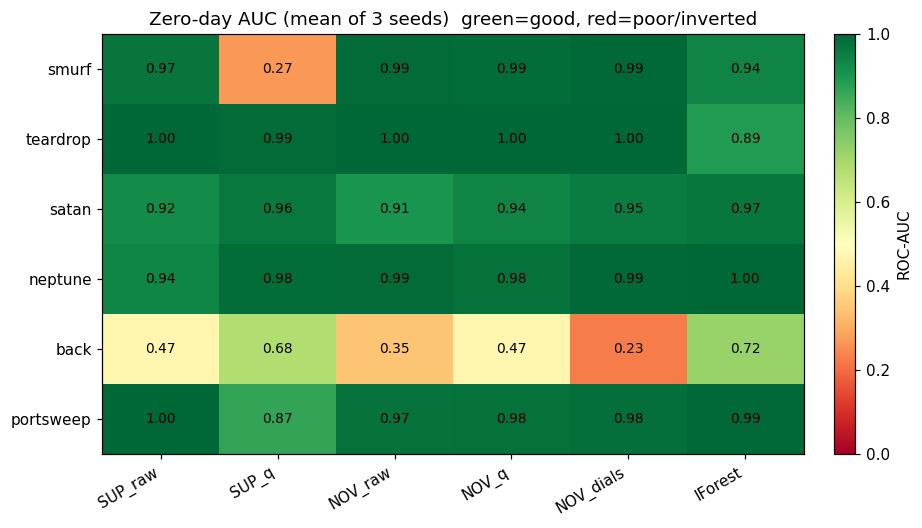

In [9]:
M = mean[DETECTORS].values
fig, ax = plt.subplots(figsize=(8.5, 0.55*len(ATTACKS)+1.6))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(DETECTORS))); ax.set_xticklabels(DETECTORS, rotation=30, ha="right")
ax.set_yticks(range(len(ATTACKS)));   ax.set_yticklabels(mean.index)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title(f"Zero-day AUC (mean of {len(SEEDS)} seeds)  green=good, red=poor/inverted")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ROC-AUC")
plt.tight_layout(); plt.show()

### 8.2 Quantum gain with error bars — SUP vs NOV

Bars above zero = quantum helps; below = quantum hurts. The black whisker is the
error bar (std across seeds). A bar is a *real* effect only when it clears its whisker.

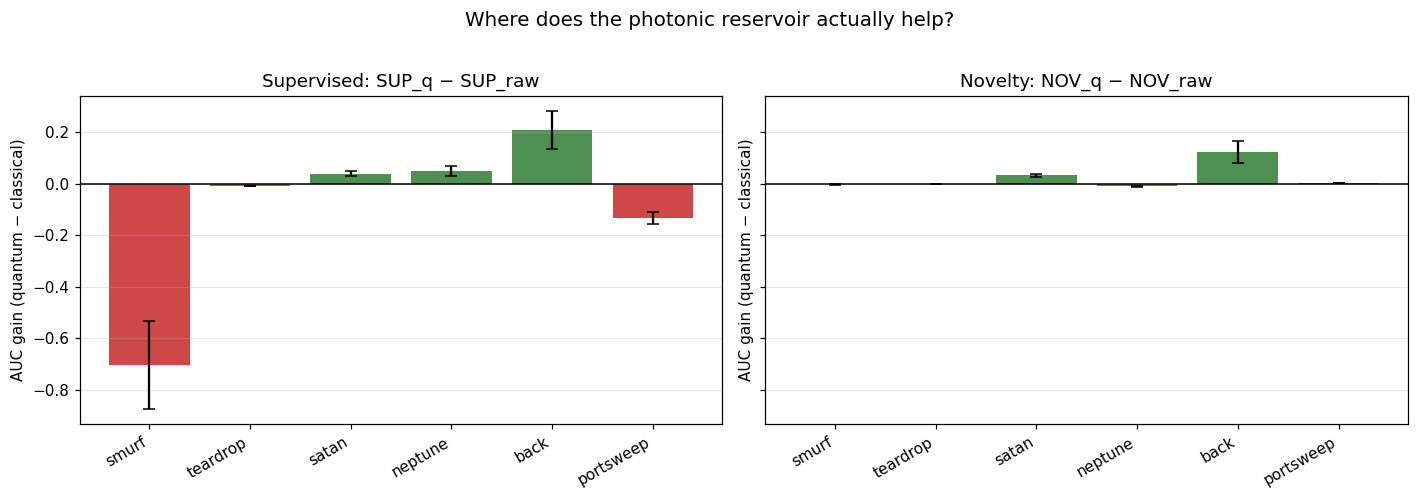

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (title, g) in zip(axes, [("Supervised: SUP_q − SUP_raw", gain_sup),
                                 ("Novelty: NOV_q − NOV_raw", gain_nov)]):
    x = np.arange(len(ATTACKS))
    vals = g["gain"].astype(float).values
    errs = g["err"].astype(float).values
    colors = ["#2E7D32" if v > 0 else "#C62828" for v in vals]
    ax.bar(x, vals, yerr=errs, color=colors, alpha=0.85, capsize=4)
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(g.index, rotation=30, ha="right")
    ax.set_title(title); ax.set_ylabel("AUC gain (quantum − classical)")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Where does the photonic reservoir actually help?", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

### 8.3 Best supervised vs best novelty per attack

Which family wins the zero-day task? For each attack we take the best supervised
AUC and the best novelty AUC (mean over seeds) and plot them side by side.

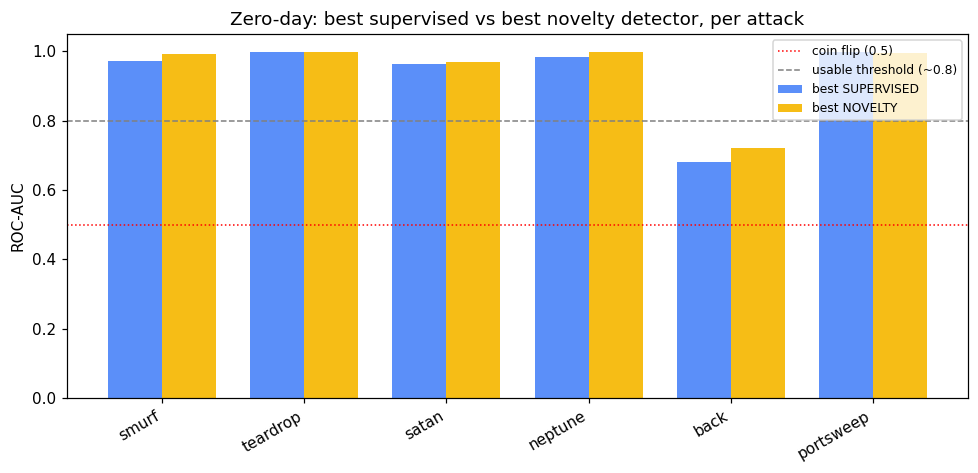

In [11]:
best_sup = mean[["SUP_raw","SUP_q"]].max(axis=1)
best_nov = mean[["NOV_raw","NOV_q","NOV_dials","IForest"]].max(axis=1)
x = np.arange(len(ATTACKS)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x-w/2, best_sup.values, w, label="best SUPERVISED", color="#5B8FF9")
ax.bar(x+w/2, best_nov.values, w, label="best NOVELTY",    color="#F6BD16")
ax.axhline(0.5, color="red", ls=":", lw=1, label="coin flip (0.5)")
ax.axhline(0.8, color="gray", ls="--", lw=1, label="usable threshold (~0.8)")
ax.set_xticks(x); ax.set_xticklabels(mean.index, rotation=30, ha="right")
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0, 1.05)
ax.set_title("Zero-day: best supervised vs best novelty detector, per attack")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 8.4 Score-distribution grid — every attack (novelty detector)

For each attack, the novelty (`NOV_dials`) score of normal-test vs the held-out
zero-day attack. Clean right-shift = detectable; heavy overlap = the honest
limitation (see `back`).

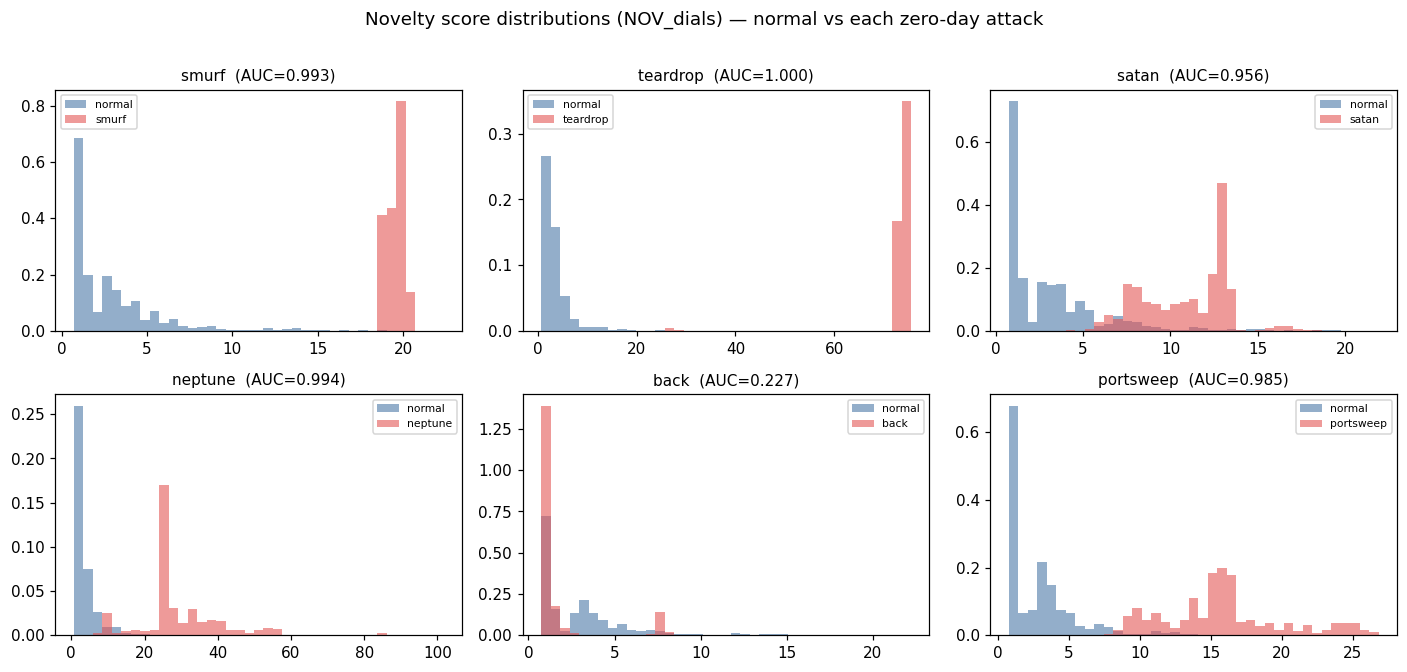

In [12]:
det = "NOV_dials"
n = len(ATTACKS); ncol = 3; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 3.0*nrow))
axes = np.array(axes).reshape(-1)
for ax, atk in zip(axes, ATTACKS):
    s_n, s_a = scores_by_atk[atk][det]
    lo, hi = min(s_n.min(), s_a.min()), np.quantile(np.r_[s_n, s_a], 0.995)
    bins = np.linspace(lo, hi, 40)
    ax.hist(s_n, bins=bins, alpha=0.6, density=True, color="#4C78A8", label="normal")
    ax.hist(s_a, bins=bins, alpha=0.6, density=True, color="#E45756", label=atk)
    ax.set_title(f"{atk}  (AUC={single[atk][det]:.3f})", fontsize=10)
    ax.legend(fontsize=7)
for ax in axes[n:]: ax.axis("off")
fig.suptitle(f"Novelty score distributions ({det}) — normal vs each zero-day attack", y=1.01)
plt.tight_layout(); plt.show()

### 8.5 ROC curves — all attacks, best novelty detector

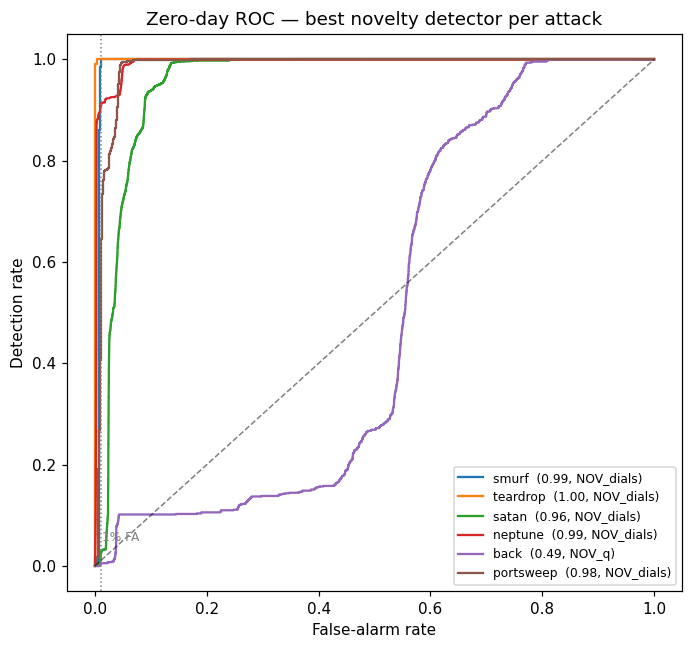

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 6))
for atk in ATTACKS:
    # pick the novelty detector with the best single-seed AUC for this attack
    best = max(["NOV_raw","NOV_q","NOV_dials"], key=lambda d: single[atk][d])
    s_n, s_a = scores_by_atk[atk][best]
    y = np.r_[np.zeros(len(s_n)), np.ones(len(s_a))]
    fpr, tpr, _ = roc_curve(y, np.r_[s_n, s_a])
    ax.plot(fpr, tpr, label=f"{atk}  ({single[atk][best]:.2f}, {best})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=.5)
ax.axvline(0.01, color="gray", ls=":", lw=1); ax.text(0.012,0.05,"1% FA",color="gray",fontsize=8)
ax.set_xlabel("False-alarm rate"); ax.set_ylabel("Detection rate")
ax.set_title("Zero-day ROC — best novelty detector per attack")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()